# Argus — Dataset Creation (CNN+LSTM Windowed Image Sequences)

The fifth model family: a hybrid `TimeDistributed(CNN) → LSTM` that sees an actual windowed
*sequence* of face-crop images (curated durations from 3s up to 20s — see "Pipeline Configuration
Constants" below — related to but deliberately not identical to
[`01_dataset_creation_lstm.ipynb`](./01_dataset_creation_lstm.ipynb)'s own multi-duration
sliding-window scheme), rather than either a single cropped image (`06`/`07`'s CNN) or
hand-engineered geometric features (the LSTM). This is the most complete fix for the
single-instant-in-time limitation that capped every other single-frame model around ~40%: it
combines raw-pixel visual cues (which plain geometric ratios can't see) with genuine temporal
context (which a single image can't see either).

**Calibrated expectation, stated plainly up front:** this is also, by a wide margin, the most
data-hungry model built so far — a deep model over raw pixel *sequences*, trained on ~24
subjects. Real overfitting risk here is higher than anywhere else in this project, not lower.
Worth trying — it's the theoretically strongest architecture for this problem — but don't assume
"more complete architecture" automatically means "better result" on a dataset this size; treat it
as a real experiment with a real chance of underperforming the LSTM, not a foregone upgrade.

**Reads:** `dataset_processed/face_crops_index.csv` and the `.jpg` files it points to, written by
[`06_dataset_creation_face_crops.ipynb`](./06_dataset_creation_face_crops.ipynb) — **run that
first if you haven't** (it hasn't produced output yet as of this notebook being written). This
notebook does **not** re-extract or re-crop anything from video — it only builds a lightweight
window *index* (frame-range references into crops that already exist), the same principle that
turned the LSTM's dataset from thousands of `.npy` files into one CSV: reuse what's already
extracted, don't multiply storage by re-saving overlapping copies of it.

**Writes:** `dataset_processed/cnn_lstm_windows_index.csv` — one row per valid window, storing an
ordered, `;`-joined list of that window's real crop image paths (not the pixels themselves; those
are decoded lazily by `10_cnn_lstm_training.ipynb`'s `tf.data` pipeline, same lazy-loading pattern
`07_cnn_training.ipynb` already uses for single images). This means dataset *creation* here never
loads or accumulates pixel data at all — regardless of window count or duration, this notebook
only ever holds path strings in memory, so it doesn't have a RAM-crash risk to design around the
way the geometric LSTM's `MAX_TIMESTEPS` did (see `01_dataset_creation_lstm.ipynb`'s note on why
`MAX_TIMESTEPS` was brought down from 120 to 60 — that was about accumulating flattened *feature*
rows in memory, a failure mode this path-only index doesn't share).


## Google Drive Connection & Project Setup


In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

project_folder = "/content/drive/MyDrive/Argus"
print(f"Google Drive successfully mounted! Base project directory: {project_folder}")


Mounted at /content/drive
Google Drive successfully mounted! Base project directory: /content/drive/MyDrive/Argus


In [2]:
import os

models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
processed_folder = f"{dataset_folder}/dataset_processed"
face_crops_folder = f"{processed_folder}/face_crops"
face_crops_index_csv_path = os.path.join(processed_folder, "face_crops_index.csv")

if not os.path.exists(face_crops_index_csv_path):
    raise FileNotFoundError(
        f"'{face_crops_index_csv_path}' not found. Run 06_dataset_creation_face_crops.ipynb "
        "first -- this notebook only indexes windows over crops it produces, it doesn't extract "
        "any crops itself."
    )

print("Project folder structure validated.")


Project folder structure validated.


## Pipeline Configuration Constants

**Curated window durations (3s/5s/10s/20s), not the geometric LSTM's dense 1s-step sweep.**
`01_dataset_creation_lstm.ipynb` builds one window config per second from 1-6s (six configs).
This notebook instead uses a small curated set spanning a wider 3-20s range — fewer, more
distinct durations means less near-duplicate redundancy between adjacent configs (a 3s and a 4s
window differ by only one frame at 1 FPS and would mostly overlap in content), and keeps the
window index a manageable size even at the wider range.

**`sampling_fps = 1`, matching `06_dataset_creation_face_crops.ipynb`'s actual rate — not 10.**
An earlier version of this notebook hardcoded `sampling_fps = 10` under the assumption that 06
sampled that densely; it doesn't (06 samples at 1 FPS, sparse, by design — see 06's own
"Pipeline Configuration Constants" section). Getting this wrong doesn't raise an error: window
sizing below is `duration_sec * sampling_fps`, so a wrong `sampling_fps` silently produces
windows of the wrong real-world duration while still looking internally consistent. Keep this in
sync with 06's real constant, not a guess.

**`MAX_TIMESTEPS_IMG = 20`, not 60.** The geometric LSTM's dataset pads to a fixed
`max_context_sec * sampling_fps`; here that's `20 * 1 = 20`. Each padded slot is a full
`(IMG_SIZE, IMG_SIZE, 3)` image tensor rather than a 58-float feature row, so padding cost scales
with tensor size — cheap regardless of headroom for a feature row, expensive for a full image.
The 1 FPS rate (vs. the geometric LSTM's 10 FPS) means this is comfortably small even at the
wider 20s (vs. 6s) max duration.


In [3]:
sampling_fps = 1                       # Must match 06_dataset_creation_face_crops.ipynb's actual
                                        # sampling_fps (1 FPS, sparse) -- NOT the geometric LSTM's
                                        # 10 FPS. Getting this wrong doesn't error -- it silently
                                        # makes every window's real duration wrong, since window
                                        # sizing below is `duration_sec * sampling_fps`.
window_configs = [3.0, 5.0, 10.0, 20.0]  # Curated durations, not a dense 1s-step sweep like
                                          # 01_dataset_creation_lstm.ipynb's -- fewer, more
                                          # distinct configs means less near-duplicate redundancy
                                          # between adjacent durations.
min_context_sec = min(window_configs)   # 3
max_context_sec = max(window_configs)   # 20

MAX_TIMESTEPS_IMG = int(max_context_sec * sampling_fps)  # 20 -- see note above on why not 60/120 here

print(f"✅ Pipeline constants initialized. Windows: {window_configs}s, MAX_TIMESTEPS_IMG={MAX_TIMESTEPS_IMG}")


✅ Pipeline constants initialized. Windows: [3.0, 5.0, 10.0, 20.0]s, MAX_TIMESTEPS_IMG=20


## Building the Window Index

For each clip `(subject, parent_video)`, tile the same 3-20s curated-duration windows over its
**already-cropped** frames (loaded from `face_crops_index.csv`). Windowing is done over
`sample_idx` -- the consecutive sampled-frame position `06` now records -- **not** `frame_idx`
(the raw video frame count, which is spaced by that video's own `frame_stride` and would make
every window spuriously fail a naive contiguity check).

**Tiled per contiguous run, not a single global grid.** A clip's available `sample_idx` values
are first split into maximal *contiguous* runs (a gap opens a new run -- some frames are missing
where the Face Detector found no confident face). Each run is then tiled independently, starting
fresh from that run's own first sample_idx. This -- rather than tiling from a single anchor
(the clip's first available sample) and discarding any window that happens to land on a gap --
avoids wasting real, usable frames: a fixed global grid can leave up to `win_size - 1` real frames
stranded on the wrong side of a gap, off-grid, even though they're perfectly good contiguous data
on their own. In a subject-scarce dataset, every extra window matters.

**Non-overlapping, not sliding.** Within one duration config, windows tile back-to-back
(`stride = win_size` -- the window's own length in samples) rather than sliding by a small fixed
step -- so a run's samples are chopped into consecutive, disjoint 3s chunks, separately disjoint
5s chunks, and so on, with no two windows *of the same duration* sharing a frame. This keeps
subject-grouped train/val/test splitting simple in the training notebook: no near-duplicate
windows straddling a split boundary within a given duration. Windows from *different* duration
configs will still cover overlapping real-time spans of the same clip -- a 3s window and a 10s
window starting at the same point obviously overlap -- but that's inherent to the multi-duration
scheme and intentional (duration diversity in what the model sees), not the kind of overlap this
is avoiding.


In [4]:
import pandas as pd
import numpy as np

df_face_crops = pd.read_csv(face_crops_index_csv_path)
if 'sample_idx' not in df_face_crops.columns:
    raise ValueError(
        "face_crops_index.csv has no 'sample_idx' column -- re-run 06_dataset_creation_face_crops.ipynb "
        "(it was updated to record this alongside frame_idx; a CSV from before that update won't have it)."
    )
df_face_crops = df_face_crops.sort_values(['subject', 'parent_video', 'sample_idx']).reset_index(drop=True)

print(f"Loaded {len(df_face_crops)} indexed crops across "
      f"{df_face_crops.groupby(['subject', 'parent_video']).ngroups} clips.")


Loaded 8959 indexed crops across 450 clips.


In [5]:
def _contiguous_runs(sorted_indices):
    """Split a sorted list of ints into maximal runs of consecutive integers -- e.g.
    [0,1,2,5,6,9] -> [(0,2),(5,6),(9,9)]. A gap in sample_idx (a frame with no confident face
    detection) starts a new run.
    """
    runs = []
    run_start = prev = sorted_indices[0]
    for idx in sorted_indices[1:]:
        if idx != prev + 1:
            runs.append((run_start, prev))
            run_start = idx
        prev = idx
    runs.append((run_start, prev))
    return runs


def build_windows_for_clip(clip_df, window_configs, sampling_fps):
    """clip_df: rows for one (subject, parent_video), already sorted by sample_idx.

    Returns a list of dicts, one per valid window: the ordered image_path list for that window's
    real (contiguous, gap-free) frames -- no padding decided here, that happens at load time in
    10_cnn_lstm_training.ipynb, mirroring how 01_dataset_creation_lstm.ipynb keeps padding out of
    the generation step for everything except the final flattened output.

    Windows are non-overlapping within each duration config (stride == window size), tiled
    separately per maximal contiguous run of sample_idx -- see the "Building the Window Index"
    markdown cell above for why tiling per-run (rather than from one global anchor) matters.
    """
    sample_idx_to_path = dict(zip(clip_df['sample_idx'], clip_df['image_path']))
    available_samples = sorted(sample_idx_to_path.keys())
    if not available_samples:
        return []

    runs = _contiguous_runs(available_samples)
    windows = []
    for win_sec in window_configs:
        win_size = int(win_sec * sampling_fps)
        for run_start, run_end in runs:
            # Every index in [start, start + win_size) is guaranteed present -- the run is
            # contiguous by construction, so no gap-check is needed here (unlike a single
            # global-anchor grid, which could land on a gap and require discarding a candidate).
            for start in range(run_start, run_end - win_size + 2, win_size):
                end = start + win_size  # exclusive
                image_paths = [sample_idx_to_path[si] for si in range(start, end)]
                windows.append({
                    'window_duration_sec': win_sec,
                    'n_real_frames': win_size,
                    'start_sample_idx': start,
                    'end_sample_idx': end - 1,
                    'image_paths': ';'.join(image_paths),
                })
    return windows


### Running the Window Builder Across All Clips


In [6]:
from tqdm.auto import tqdm

rows = []
skipped = []

grouped = df_face_crops.groupby(['subject', 'parent_video'], sort=False)

for (subject, parent_video), clip_df in tqdm(grouped, desc="Building windows per clip"):
    level = clip_df['level'].iloc[0]  # constant per clip -- 06 already resolved subject-aware mapping

    clip_windows = build_windows_for_clip(clip_df, window_configs, sampling_fps)
    if not clip_windows:
        skipped.append((subject, parent_video, "No valid (gap-free) window of any configured duration"))
        continue

    for w in clip_windows:
        w['subject'] = subject
        w['parent_video'] = parent_video
        w['level'] = level
        rows.append(w)

print(f"\nBuilt {len(rows)} windows across {grouped.ngroups} clips.")
if skipped:
    print(f"Skipped {len(skipped)} clips with no valid window:")
    for subject, parent_video, reason in skipped[:10]:
        print(f"   - {subject}/{parent_video}: {reason}")
    if len(skipped) > 10:
        print(f"   ... and {len(skipped) - 10} more")


Building windows per clip:   0%|          | 0/450 [00:00<?, ?it/s]


Built 5763 windows across 450 clips.


### Writing the Window Index CSV


In [7]:
cnn_lstm_windows_csv_path = os.path.join(processed_folder, "cnn_lstm_windows_index.csv")

df_cnn_lstm_windows = pd.DataFrame(rows)
df_cnn_lstm_windows.to_csv(cnn_lstm_windows_csv_path, index=False)

print(f"✅ Window index written: {cnn_lstm_windows_csv_path}")
print(f"   Shape: {df_cnn_lstm_windows.shape}")


✅ Window index written: /content/drive/MyDrive/Argus/dataset/dataset_processed/cnn_lstm_windows_index.csv
   Shape: (5763, 8)


### Dataset Sanity Check

Verify class balance across windows, and preview one window's frame sequence to confirm the paths resolve to real, temporally-ordered images.


--- Dataset Sanity Check ---
Total windows: 5763
Distinct subjects: 54
Window duration distribution:
window_duration_sec
3.0     2674
5.0     1771
10.0     882
20.0     436
Name: count, dtype: int64

Window counts per level:
  Level 1: 1895 windows
  Level 2: 1947 windows
  Level 3: 1921 windows

✅ Success: All 3 levels are present in the dataset.

✅ No overlapping windows within any duration config

Previewing a 20.0s window (20 frames, 20.0s elapsed at 1 FPS), subject=subject_21, level=3:


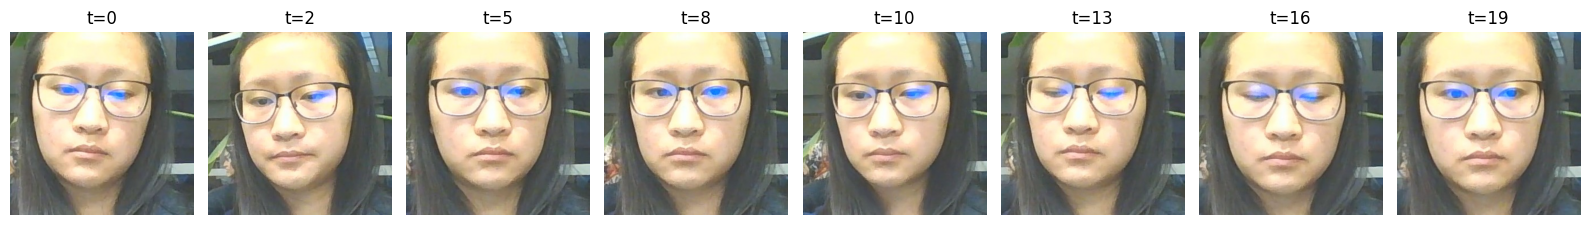

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

df_cnn_lstm_windows = pd.read_csv(cnn_lstm_windows_csv_path)
level_counts = df_cnn_lstm_windows['level'].value_counts().sort_index()

print("--- Dataset Sanity Check ---")
print(f"Total windows: {len(df_cnn_lstm_windows)}")
print(f"Distinct subjects: {df_cnn_lstm_windows['subject'].nunique()}")
print(f"Window duration distribution:\n{df_cnn_lstm_windows['window_duration_sec'].value_counts().sort_index()}")
print("\nWindow counts per level:")
for lvl, count in level_counts.items():
    print(f"  Level {lvl}: {count} windows")

missing_levels = [l for l in [1, 2, 3] if l not in level_counts.index]
if not missing_levels:
    print("\n✅ Success: All 3 levels are present in the dataset.")
else:
    print(f"\n⚠️ Warning: Missing levels {missing_levels} in the processed data.")

# --- Non-overlap spot check ---
# For each (subject, parent_video, window_duration_sec) group, consecutive windows (sorted by
# start_sample_idx) must not overlap: end_sample_idx of window n < start_sample_idx of window n+1.
# A violation here would mean the tiling logic in build_windows_for_clip regressed back toward
# sliding-window behavior. Written with groupby().shift() rather than groupby().apply() so it
# doesn't depend on a specific pandas version's apply/include_groups behavior.
group_cols = ['subject', 'parent_video', 'window_duration_sec']
df_sorted = df_cnn_lstm_windows.sort_values(group_cols + ['start_sample_idx'])
prev_end_sample_idx = df_sorted.groupby(group_cols)['end_sample_idx'].shift(1)
overlap_found = (prev_end_sample_idx >= df_sorted['start_sample_idx']).fillna(False).any()
print(f"\n{'❌ Overlap detected' if overlap_found else '✅ No overlapping windows within any duration config'}")

# Preview one 20-second window's frame sequence to visually confirm temporal ordering and
# elapsed duration -- printing the real elapsed time explicitly is a cheap, direct way to catch a
# future sampling_fps mismatch (like the one this notebook previously had) on sight, rather than
# it silently producing wrong-duration windows again.
sample = df_cnn_lstm_windows[df_cnn_lstm_windows['window_duration_sec'] == max_context_sec].sample(1, random_state=0).iloc[0]
sample_paths = sample['image_paths'].split(';')
elapsed_sec = sample['n_real_frames'] / sampling_fps
print(f"\nPreviewing a {sample['window_duration_sec']}s window ({len(sample_paths)} frames, "
      f"{elapsed_sec:.1f}s elapsed at {sampling_fps} FPS), subject={sample['subject']}, level={sample['level']}:")

n_preview = min(8, len(sample_paths))
preview_idx = np.linspace(0, len(sample_paths) - 1, n_preview, dtype=int)
fig, axes = plt.subplots(1, n_preview, figsize=(2 * n_preview, 2.5))
for ax, idx in zip(axes, preview_idx):
    ax.imshow(mpimg.imread(sample_paths[idx]))
    ax.set_title(f"t={idx}")
    ax.axis('off')
plt.tight_layout()
plt.show()
